In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2025_Speckle_Flow_Networks_QIP/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

import torch
from torch import nn, Tensor
from torchvision.models.optical_flow import raft_large
from torchvision.models.optical_flow import Raft_Large_Weights
import torchvision.transforms.functional as F
from torchvision.utils import flow_to_image
from torch.utils.tensorboard import SummaryWriter

from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator

from typing import Optional, Union

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


In [2]:
def generate_ref_obj_wavefields(RI_distribution, phase_mask, dist_m_im, dist_m_im_var,
                                wl, n_background, spatial_resolution, spatial_support, mag, padding=256, NA=1):

    k = 2*np.pi/wl
    output_field = propagator.propagate_beam_2(np.ones_like(RI_distribution[..., 1]), RI_distribution, n_background, wl, spatial_resolution)
    
    # prop to focal plane
    output_field = propagator.propagate(output_field, wl/n_background, spatial_resolution, spatial_support[2]/2, padding=padding, direction='backward')

    # NA based low-pass filtering
    # output_field = utils.low_pass_filter_NA(output_field, wl, spatial_resolution, NA)
    
    # prop back to mask plane from image plane (plus variation) ensures focus plane imaging
    output_field = propagator.propagate(output_field, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='backward')
    output_field = gaussian_filter(output_field, np.random.rand() + 3.) # smoothing -> partial spatial coherence
    
    # ground truth flow
    flow_y, flow_x = utils.grad_optr(np.angle(output_field))
    gt_flow_y = (np.remainder(flow_y + np.pi, 2*np.pi) - np.pi)/(spatial_resolution[0]*mag)**2/k*(dist_m_im + dist_m_im_var)
    gt_flow_x = (np.remainder(flow_x + np.pi, 2*np.pi) - np.pi)/(spatial_resolution[1]*mag)**2/k*(dist_m_im + dist_m_im_var)
    
    # mask modulation and prop to image plane
    output_field = propagator.propagate(output_field*phase_mask, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    ref_field = propagator.propagate(phase_mask, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    
    return ref_field[5:-5, 5:-5], output_field[5:-5, 5:-5], [-1*gt_flow_x[5:-5, 5:-5], -1*gt_flow_y[5:-5, 5:-5]]


def create_phase_mask(height_range, grid_shape, tile_size, wl, RI_pm):
    h_pm = wl/np.random.randint(height_range[0], height_range[1])
    hmap_pm = geometry.initialize_hmap_uniform_sampling(grid_shape[:2], tile_size, h_pm)
    opd_pm = hmap_pm*RI_pm + (hmap_pm.max() - hmap_pm)*1. # phase mask in air
    
    return np.exp(1j*(2*np.pi/wl)*opd_pm)


# model
def init_model_RAFT(model, device='cuda', checkpoint=None):
    
    if checkpoint == None:
        print('Loading models with pretrained weights')
        weights = Raft_Large_Weights.DEFAULT.get_state_dict()
        weights['feature_encoder.convnormrelu.0.weight'] = torch.mean(weights['feature_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
        weights['context_encoder.convnormrelu.0.weight'] = torch.mean(weights['context_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
    else:
        print(f'Loading models with checkpoint: {checkpoint}')
        weights = torch.load(checkpoint, map_location=torch.device(device))
    
    # model = raft_large(progress=False)
    model.feature_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    model.context_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    
    model.load_state_dict(weights)
    
    return model.to(device)
    

def RAFT_loss(predictions, target, device='cuda'):
	loss_fn = torch.nn.L1Loss()
	N = len(predictions)
	
	w = torch.pow(torch.tensor(0.8), N-torch.tensor(range(1, N+1))).to(device)
	loss_n = torch.sum(torch.abs(torch.stack(predictions, dim=0) - target.unsqueeze(0).repeat(12, 1, 1, 1, 1)), dim=[1, 2, 3, 4])
	
	return torch.sum(w*loss_n).squeeze()


def plot(imgs, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    plt.tight_layout()

In [3]:
epochs = 1
update_wegiths_iter = 1

# Grid and propagation parameters setup
wl = 640e-9
spatial_resolution = [200e-9, 200e-9, 200e-9] # dx, dy, dz
grid_shape = [500, 500, 200] # x=0->, y=0->, z=0->
n_background = 1.33 # immersion medium RI
spatial_support = [spatial_resolution[i]*grid_shape[i] for i in range(3)]

c_m = [50e-6, 50e-6, 20e-6]
c_v = [15e-6, 15e-6, 3e-9]
rad_params = [2, 15, 1e-6]
RI_params = [1.35, 1e-6]

dist_m_im = 1e-3 # meters
pad = 512
mag = 10

side_length = 10e-6
tile_size = int(side_length/(spatial_resolution[0]*mag))
RI_pm = 1.46
# h_pm = wl/(2*(RI_pm - 1.))

int_gaus_noise = 1e-1

geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)

Coordiante system with size: 
 
              X = [0, 1.00e-04], Res_X = 2e-07
              Y = [0, 1.00e-04], Res_Y = 2e-07
              Z = [0, 4.00e-05], Res_Z = 2e-07
              Immersion RI: 1.33
      


In [4]:
for it1 in range(epochs):
    
    # generate phase mask
    phase_mask = create_phase_mask([2, 5], grid_shape, tile_size, wl, RI_pm)

    
    for it2 in range(update_wegiths_iter):
        
        # generate data 3D tensor
        num_elements = np.random.randint(1, 20)
        print(f'{it1}:{it2}-{num_elements}')
        
        RI_distribution_1 = geometry.generate_bead_data(geom, c_m, c_v, rad_params, RI_params, num_elements).get_grid()
        geom.reset_grid() # sets back to background RI. Initialization not required again.
        
        # generate NN input and label
        dist_m_im_var = np.random.randn()*1e-3*0
        ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields(RI_distribution_1, phase_mask, dist_m_im, dist_m_im_var,
                                    wl, n_background, spatial_resolution, spatial_support, mag, padding=256, NA=1)
        
        img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave))**2 + int_gaus_noise*torch.randn(490, 490), min=0).float()
        img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave))**2 + int_gaus_noise*torch.randn(490, 490), min=0).float()

0:0-16


Text(0.5, 1.0, 'Object Wave Phase at Sensor')

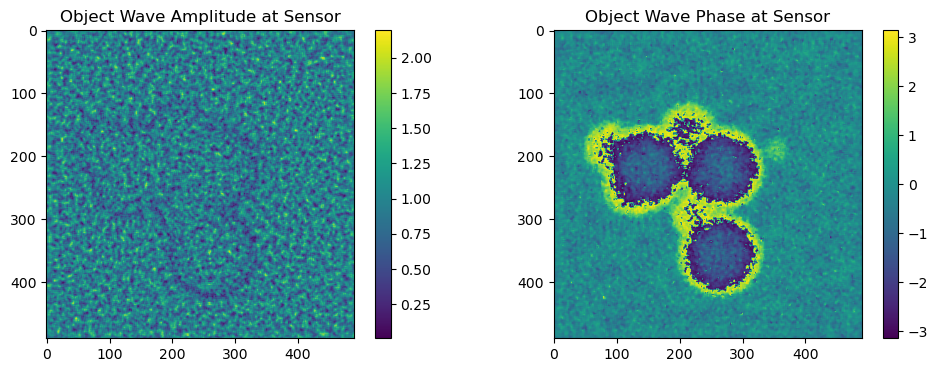

In [5]:
fx, axs = plt.subplots(1, 2, figsize=(12, 4))

im1 = axs[0].imshow(np.abs(obj_wave))
plt.colorbar(im1, ax=axs[0])
axs[0].set_title('Object Wave Amplitude at Sensor')

im2 = axs[1].imshow(np.angle(obj_wave))
plt.colorbar(im2, ax=axs[1])
axs[1].set_title('Object Wave Phase at Sensor')

In [6]:
I0 = img_ref/img_ref.max()
I1 = img_obj/img_obj.max()

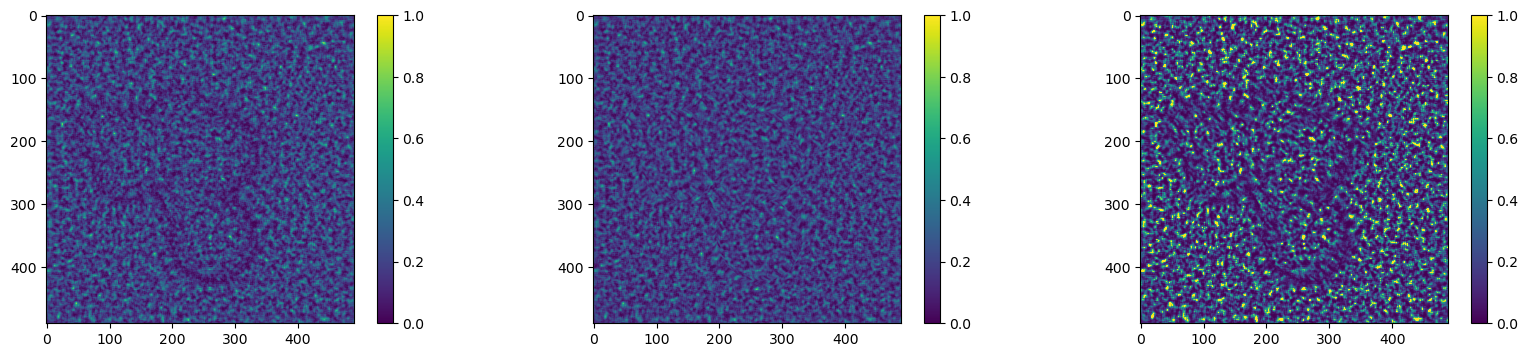

In [15]:
# init grid
x = torch.linspace(-1, 1, I0.shape[0], dtype=torch.float64)
y = torch.linspace(-1, 1, I0.shape[1], dtype=torch.float64)
X_grid, Y_grid = torch.meshgrid((x, y)) # 1d data but grid sample works for 2d

X_grid_warped = X_grid - gt_flow[0]/I0.shape[0]*2
# X_grid_clamped = X_grid_warped.clamp(-1, 1)
Y_grid_warped = Y_grid - gt_flow[1]/I1.shape[0]*2
# Y_grid_clamped = Y_grid_warped.clamp(-1, 1)

grid = torch.stack((Y_grid_warped, X_grid_warped), dim=0).permute(1, 2, 0).unsqueeze(0)  # Shape: (1, N, 1, 2)
I_est = torch.nn.functional.grid_sample(I0.unsqueeze(0).unsqueeze(0).float(), grid.float(), align_corners=True, mode='bilinear').squeeze()

fig, axs = plt.subplots(1, 3, figsize=(20, 4))

im1 = axs[0].imshow(I1, vmax=1., vmin=0.)
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(I_est, vmax=1., vmin=0.)
# im2 = axs[1].imshow(I_est*gaussian_filter(occurrence_map, 3)/5, vmax=1., vmin=0.)
plt.colorbar(im2, ax=axs[1])

# im3 = axs[2].imshow((I_est)/(gaussian_filter((gt_flow[0]**2 + gt_flow[1]**2)**0.5, 1) + 5))

lap = torch.gradient(torch.tensor(gt_flow[0]/I0.shape[0]*2), dim=0)[0] + torch.gradient(torch.tensor(gt_flow[1]/I0.shape[0]*2), dim=1)[0]
# A = torch.abs(torch.tensor(propagator.propagate(obj_wave, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, padding=256, direction='forward')))**2
A = torch.abs(torch.tensor(obj_wave))**2
# A = A/A.max()
# A = 1
im3 = axs[2].imshow(A*I_est*(1 - lap), vmax=1., vmin=0)
plt.colorbar(im3, ax=axs[2])

plt.show()

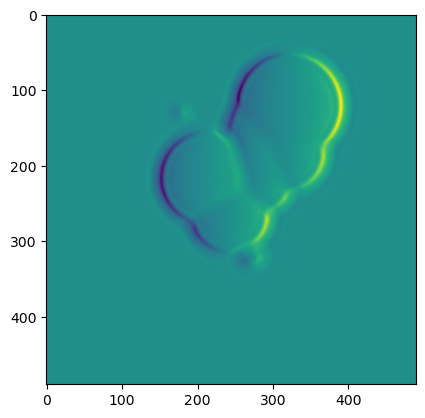

(tensor([[0.0245, 0.0286, 0.0328, 0.0369, 0.0411],
         [0.0245, 0.0286, 0.0327, 0.0369, 0.0410],
         [0.0244, 0.0285, 0.0327, 0.0367, 0.0408],
         [0.0243, 0.0285, 0.0325, 0.0366, 0.0407],
         [0.0242, 0.0283, 0.0324, 0.0365, 0.0405]], dtype=torch.float64),
 tensor([[0.0225, 0.0266, 0.0307, 0.0348, 0.0389],
         [0.0225, 0.0266, 0.0307, 0.0348, 0.0389],
         [0.0225, 0.0266, 0.0307, 0.0348, 0.0389],
         [0.0225, 0.0266, 0.0307, 0.0348, 0.0389],
         [0.0225, 0.0266, 0.0307, 0.0348, 0.0389]], dtype=torch.float64))

In [ ]:
plt.imshow(torch.tensor(gt_flow[0]/I0.shape[0]*2))
plt.show()

Y_grid_warped[250:255, 250:255], Y_grid[250:255, 250:255]

In [ ]:
for 
torch.sort(torch.round(X_grid_warped.ravel(), decimals=3))

torch.return_types.sort(
values=tensor([0.0210, 0.0210, 0.0210, 0.0210, 0.0210, 0.0250, 0.0250, 0.0250, 0.0250,
        0.0260, 0.0290, 0.0290, 0.0290, 0.0300, 0.0300, 0.0330, 0.0330, 0.0340,
        0.0340, 0.0340, 0.0370, 0.0370, 0.0380, 0.0380, 0.0380],
       dtype=torch.float64),
indices=tensor([ 1,  2,  3,  4,  0,  6,  7,  8,  9,  5, 12, 14, 13, 11, 10, 18, 19, 15,
        16, 17, 23, 24, 20, 21, 22]))

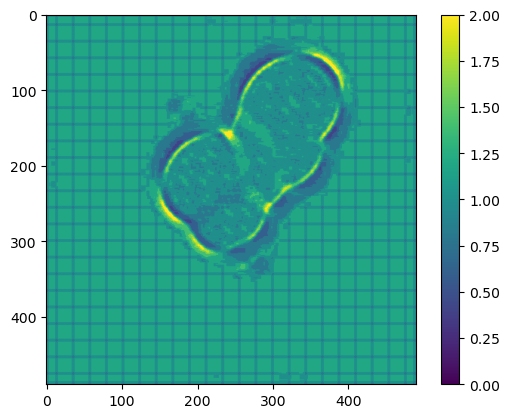

In [ ]:
import numpy as np

X_grid = torch.round(X_grid, decimals=2)
Y_grid = torch.round(Y_grid, decimals=2)

X_grid_warped = torch.round(X_grid_warped, decimals=2)
Y_grid_warped = torch.round(Y_grid_warped, decimals=2)

# Combine coordinates
regular_coords = np.stack([X_grid.flatten(), Y_grid.flatten()], axis=1)
warped_coords = np.stack([X_grid_warped.flatten(), Y_grid_warped.flatten()], axis=1)

# Convert to tuple for hashable dictionary keys
warped_tuples = [tuple(coord) for coord in warped_coords]
regular_tuples = [tuple(coord) for coord in regular_coords]

# Count occurrences of warped coordinates
from collections import Counter
warped_counts = Counter(warped_tuples)

# Map counts for each regular grid coordinate
occurrence_map = np.array([warped_counts.get(coord, 0) for coord in regular_tuples], dtype=int)
occurrence_map = occurrence_map.reshape(I0.shape[0], I0.shape[1])

plt.imshow(gaussian_filter(occurrence_map, 2)/5, vmax=2, vmin=0)
plt.colorbar()
plt.show()

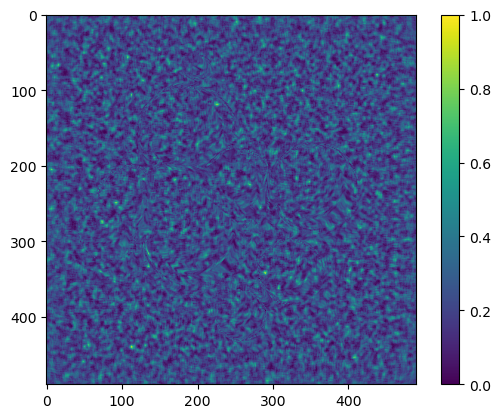

In [ ]:
# init grid
x = torch.linspace(-1, 1, I0.shape[0], dtype=torch.float64)
y = torch.linspace(-1, 1, I0.shape[1], dtype=torch.float64)
X_grid, Y_grid = torch.meshgrid((x, y)) # 1d data but grid sample works for 2d

interp = RegularGridInterpolator((x, y), I0, bounds_error=False, fill_value=None)

gt_flow_x_2 = np.where(gt_flow[0]>1e-1, gt_flow[0], 0.)
gt_flow_y_2 = np.where(gt_flow[1]>1e-1, gt_flow[1], 0.)

I1_est = interp((X_grid+gt_flow_x_2/I0.shape[0]*2, Y_grid+gt_flow_y_2/I0.shape[0]*2))

plt.imshow(I1_est, vmax=1, vmin=0)
plt.colorbar()
plt.show()

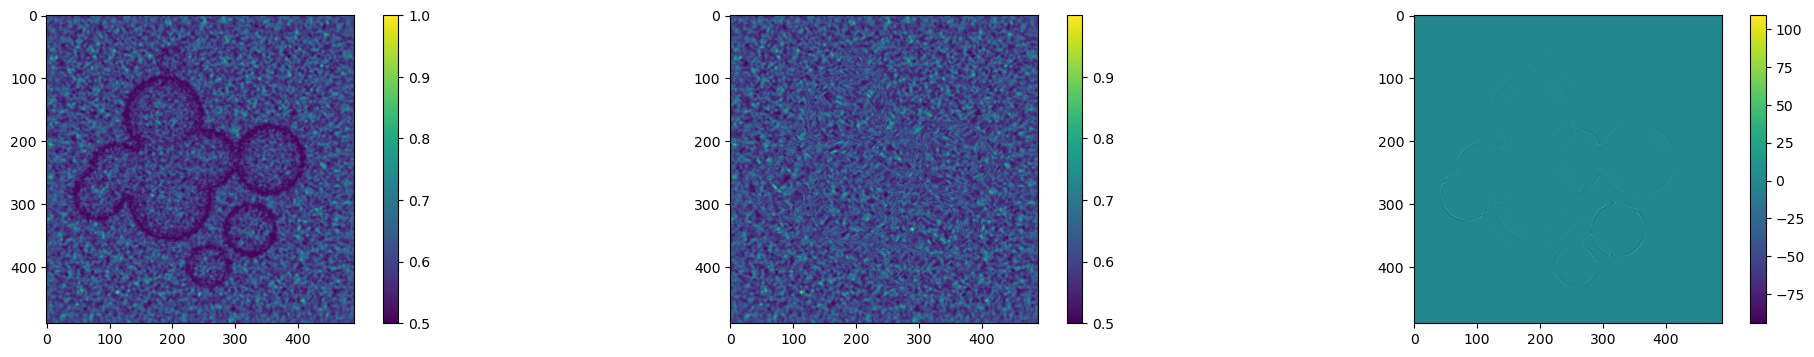

In [ ]:
# init grid
x = torch.linspace(-1, 1, I0.shape[0], dtype=torch.float64)
y = torch.linspace(-1, 1, I0.shape[1], dtype=torch.float64)
X_grid, Y_grid = torch.meshgrid((x, y)) # 1d data but grid sample works for 2d

X_grid_warped = X_grid - gt_flow[0]/I0.shape[0]*2
# X_grid_clamped = X_grid_warped.clamp(-1, 1)
Y_grid_warped = Y_grid - gt_flow[1]/I0.shape[1]*2
# Y_grid_clamped = Y_grid_warped.clamp(-1, 1)

grid = torch.stack((Y_grid_warped, X_grid_warped), dim=0).permute(1, 2, 0).unsqueeze(0)  # Shape: (1, N, 1, 2)
I_est = torch.nn.functional.grid_sample(I0.unsqueeze(0).unsqueeze(0).float(), grid.float(), align_corners=True, mode='bilinear').squeeze()

fig, axs = plt.subplots(1, 3, figsize=(25, 4))

im1 = axs[0].imshow((I1+1)/2)
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(((I_est+1)/2))
plt.colorbar(im2, ax=axs[1])

lap = torch.gradient(torch.tensor(gt_flow[0]), dim=0)[0] + torch.gradient(torch.tensor(gt_flow[1]), dim=1)[0]
im3 = axs[2].imshow(((I_est+1)/2)*(1 + lap))
# torch.softmax(lap)
plt.colorbar(im3, ax=axs[2])

plt.show()



In [ ]:
plt.imshow(lap, vmin=-5, vmax=5)
plt.colorbar()